In [80]:
import cv2 
import os, glob

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [81]:
# Image data directories
image_dir_training = "/home/mtumalan/Desktop/Repos/Clases/ConcentracionIA/Octavio(Imagenes)/DL_Data_sets/images/day_night_images/training/"
image_dir_test = "/home/mtumalan/Desktop/Repos/Clases/ConcentracionIA/Octavio(Imagenes)/DL_Data_sets/images/day_night_images/test"

In [82]:
def load_dataset(image_dir):
    
    # Populate this empty image list
    im_list = []
    image_types = ["day", "night"]
    
    # Iterate through each color folder
    for im_type in image_types:
        
        # Iterate through each image file in each image_type folder
        # glob reads in any image with the extension "image_dir/im_type/*"
        for file in glob.glob(os.path.join(image_dir, im_type, "*")):
            
            # Read in the image
            im = cv2.imread(file)
            
            # Check if the image exists/if it's been correctly read-in
            if not im is None:
                # Append the image, and it's type (red, green, yellow) to the image list
                im_list.append((im, im_type))

    return im_list

In [83]:
IMAGE_LIST = load_dataset(image_dir_training)
image_index = 6

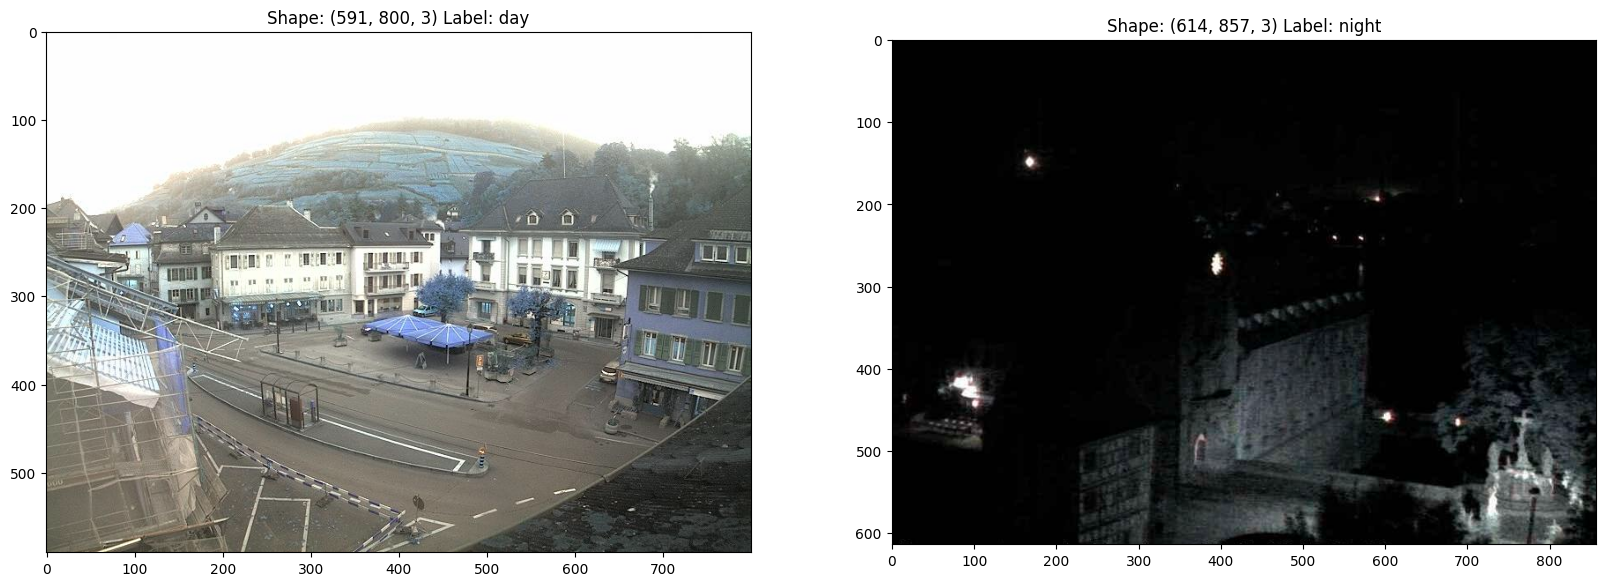

In [84]:
selected_image = IMAGE_LIST[image_index][0]
selected_label = IMAGE_LIST[image_index][1]

f, (ax1, ax2) = plt.subplots(1, 2, figsize=(20,10))

ax1.set_title("Shape: " + str(selected_image.shape) + " Label: " + selected_label)
ax1.imshow(selected_image)

selected_image = IMAGE_LIST[image_index + 150][0]
selected_label = IMAGE_LIST[image_index + 150][1]

ax2.set_title("Shape: " + str(selected_image.shape) + " Label: " + selected_label)
ax2.imshow(selected_image)

plt.show()

In [85]:
## Standardize the output using both functions above, standardize the input images and output labels
def standardize(image_list, target_size=(224, 224)):
    
    # Empty image data array
    standard_list = []

    # Iterate through all the image-label pairs
    for item in image_list:
        image, label = item[0], item[1]

        # Standardize the image
        standardized_im = cv2.resize(image, target_size)

        # Convert the label to numerical value: day=1, night=0
        if label.lower() == 'day':
            numerical_label = 1
        elif label.lower() == 'night':
            numerical_label = 0
        else:
            raise ValueError(f"Unknown label: {label}")

        standard_list.append({'image': standardized_im, 'label': numerical_label})
        
        
    return standard_list

In [86]:
STANDARDIZED_LIST = standardize(IMAGE_LIST)
print(len(STANDARDIZED_LIST))

240


Shape: ((224, 224, 3))
Label [1 = day, 0 = night]: 1


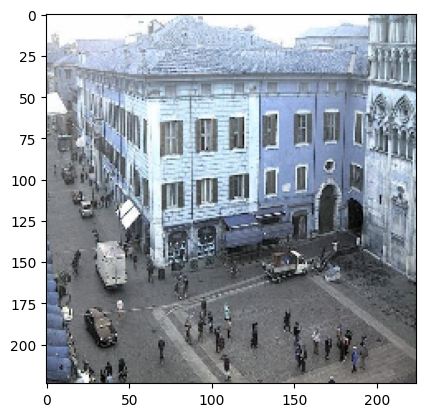

In [87]:
# Select an image by index
image_num = 0
selected_image = STANDARDIZED_LIST[image_num]['image']
selected_label = STANDARDIZED_LIST[image_num]['label']

# Display image and data about it
plt.imshow(selected_image)
print(f"Shape: ({selected_image.shape})")
print(f"Label [1 = day, 0 = night]: {selected_label}")

In [88]:
def feature_extraction(rgb_image):
    # Convert the image to HSV color space
    hsv_image = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2HSV)
    
    # Compute the color histogram for each channel
    hist_h = cv2.calcHist([hsv_image], [0], None, [256], [0, 256])
    hist_s = cv2.calcHist([hsv_image], [1], None, [256], [0, 256])
    hist_v = cv2.calcHist([hsv_image], [2], None, [256], [0, 256])
    
    # Normalize the histograms
    hist_h = cv2.normalize(hist_h, hist_h).flatten()
    hist_s = cv2.normalize(hist_s, hist_s).flatten()
    hist_v = cv2.normalize(hist_v, hist_v).flatten()
    
    # Concatenate histograms to form the feature vector
    feature_vector = np.concatenate([hist_h, hist_s, hist_v])
    
    return feature_vector

              precision    recall  f1-score   support

           0       1.00      0.96      0.98        24
           1       0.96      1.00      0.98        24

    accuracy                           0.98        48
   macro avg       0.98      0.98      0.98        48
weighted avg       0.98      0.98      0.98        48



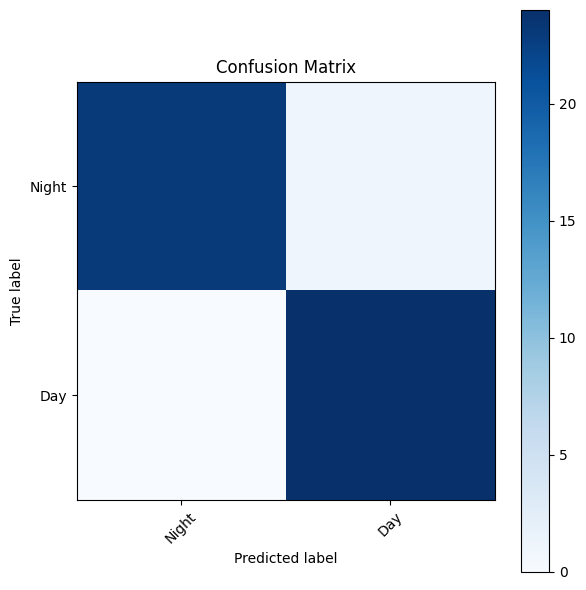

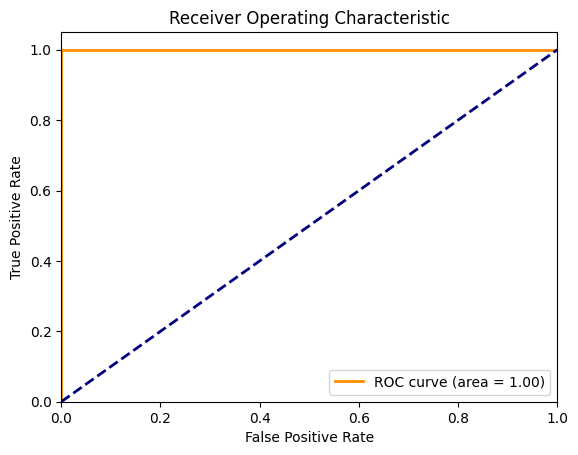

In [89]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt

def classify_day_night(image_list):
    # Extract features and labels
    features = []
    labels = []
    for item in image_list:
        image, label = item['image'], item['label']
        features.append(feature_extraction(image))
        labels.append(label)
    
    features = np.array(features)
    labels = np.array(labels)
    
    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)
    
    # Train a Logistic Regression classifier
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train, y_train)
    
    # Evaluate the classifier
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]
    
    # Print classification report
    print(classification_report(y_test, y_pred))
    
    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(2)
    plt.xticks(tick_marks, ['Night', 'Day'], rotation=45)
    plt.yticks(tick_marks, ['Night', 'Day'])
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()
    
    # Plot ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc='lower right')
    plt.show()

    return clf

# Example usage
# Assuming STANDARDIZED_LIST is already defined and contains the standardized images and labels
cdn = classify_day_night(STANDARDIZED_LIST)

Number of misclassified images: 5


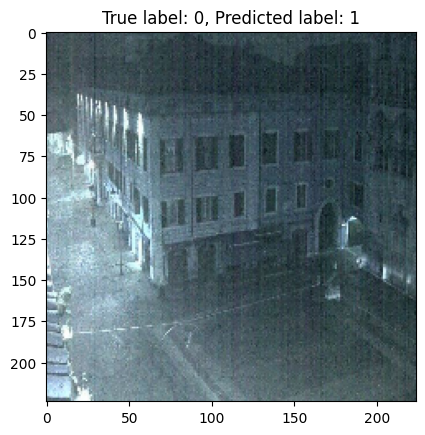

In [90]:
import random

# Using the load_dataset function in helpers.py
# Load test data
TEST_IMAGE_LIST = load_dataset(image_dir_test)

# Standardize the test data
STANDARDIZED_TEST_LIST = standardize(TEST_IMAGE_LIST)

# Shuffle the standardized test data
random.shuffle(STANDARDIZED_TEST_LIST)

# Test the model on the standardized test data
misclassified_images = []

for item in STANDARDIZED_TEST_LIST:
    image, true_label = item['image'], item['label']
    feature_vector = feature_extraction(image)
    predicted_label = cdn.predict([feature_vector])[0]
    
    if predicted_label != true_label:
        misclassified_images.append((image, true_label, predicted_label))

print(f"Number of misclassified images: {len(misclassified_images)}")

# Visualize misclassified example(s)
if misclassified_images:
    # Select the first misclassified image
    misclassified_image, true_label, predicted_label = misclassified_images[0]
    
    # Display the image
    plt.imshow(misclassified_image)
    plt.title(f"True label: {true_label}, Predicted label: {predicted_label}")
    plt.show()
else:
    print("No misclassified images to display.")